In [10]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk

# Import Json, this will be needed to load log files
import json

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [25]:
# Define a 1d chain
L = 22
g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, N=g.n_nodes)
ha = -1.0 * nk.operator.Heisenberg(hilbert=hi, graph=g)
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
print('The exact ground-state energy is E0=',exact_gs_energy)

The exact ground-state energy is E0= -22.00000000000005


In [12]:
from flax import nnx
import jax.numpy as jnp
import jax

class Jastrow(nnx.Module):
    def __init__(self, N: int, *, rngs: nnx.Rngs):
        k1, k2 = jax.random.split(rngs.params())
        self.J = nnx.Param(0.01 * jax.random.normal(k1, (N, N),
                                                    dtype=jnp.complex128))

        self.v_bias = nnx.Param(0.01 * jax.random.normal(k2, (N, 1),
                                                         dtype=jnp.complex128))

    def __call__(self, x):
        x = x.astype(jnp.complex128)              # keep the dtypes aligned
        quad = jnp.einsum('...i,ij,...j->...', x, self.J, x)
        lin  = jnp.squeeze(x @ self.v_bias, -1)   # (...,N) @ (N,1) → (...,1)
        return quad + lin

In [13]:
ma = Jastrow(N=hi.size, rngs=nnx.Rngs(0))
print(ma)

Jastrow( # Param: 156 (2.5 KB)
  J=Param( # 144 (2.3 KB)
    value=Array(shape=(12, 12), dtype=dtype('complex128'))
  ),
  v_bias=Param( # 12 (192 B)
    value=Array(shape=(12, 1), dtype=dtype('complex128'))
  )
)


In [14]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=True)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(300, out='Jastrow')
end = time.time()

print('### Jastrow calculation')
print('Has',nk.jax.tree_size(vs.parameters),'parameters')
print('The Jastrow calculation took',end-start,'seconds')

  0%|                                                                                                         …

### Jastrow calculation
Has 156 parameters
The Jastrow calculation took 7.736947774887085 seconds


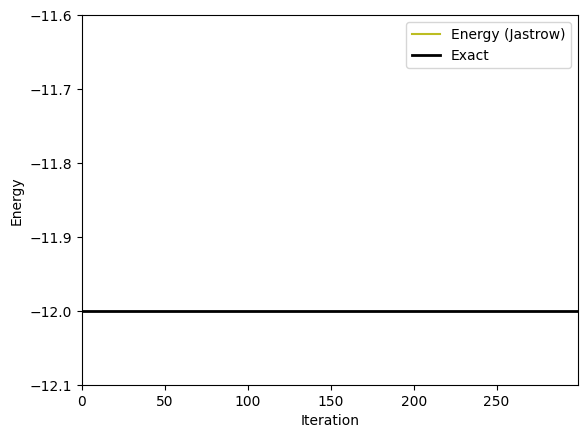

In [15]:
# import the data from log file
data_Jastrow=json.load(open("Jastrow.log"))
   
iters_Jastrow = data_Jastrow["Energy"]["iters"]
energy_Jastrow = data_Jastrow["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_Jastrow[-1],exact_gs_energy-0.1,exact_gs_energy+0.4])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_Jastrow[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [16]:
# RBM ansatz with alpha=1
ma = nk.models.RBM(alpha=1)

In [17]:
# Build the sampler
sa = nk.sampler.MetropolisExchange(hilbert=hi,graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBM', n_iter=600)
end = time.time()

print('### RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The RBM calculation took',end-start,'seconds')

  0%|                                                                                                         …

### RBM calculation
Has 168 parameters
The RBM calculation took 12.392221927642822 seconds


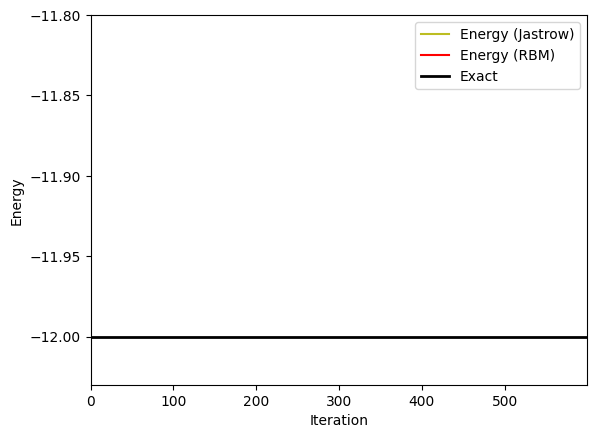

In [18]:
# import the data from log file
data=json.load(open("RBM.log"))
   
# Extract the relevant information
iters_RBM = data["Energy"]["iters"]
energy_RBM = data["Energy"]["Mean"]
    
fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_RBM[-1],exact_gs_energy-0.03,exact_gs_energy+0.2])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [19]:
## Symmetric RBM Spin Machine
ma = nk.models.RBMSymm(symmetries=g.translation_group(), alpha=1)

# Metropolis Exchange Sampling
# Notice that this sampler exchanges two neighboring sites
# thus preservers the total magnetization
sa = nk.sampler.MetropolisExchange(hi, graph=g)

# Optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1008)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)

start = time.time()
gs.run(out='RBMSymmetric', n_iter=300)
end = time.time()

print('### Symmetric RBM calculation')
print('Has',vs.n_parameters,'parameters')
print('The Symmetric RBM calculation took',end-start,'seconds')

  0%|                                                                                                         …

### Symmetric RBM calculation
Has 14 parameters
The Symmetric RBM calculation took 7.054536581039429 seconds


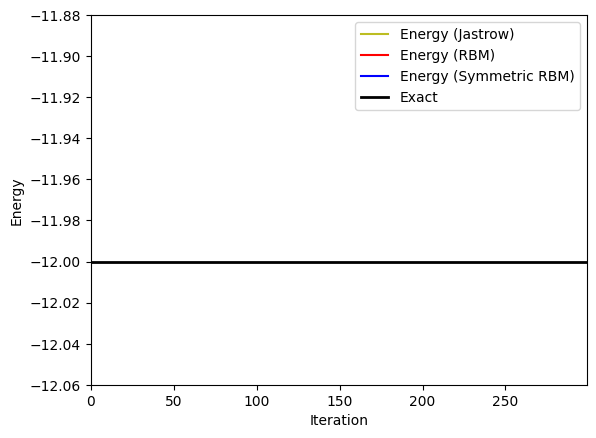

In [20]:
## import the data from log file
data=json.load(open("RBMSymmetric.log"))

# Extract the relevant information
iters_symRBM = data["Energy"]["iters"]
energy_symRBM = data["Energy"]["Mean"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8', label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
ax1.plot(iters_symRBM, energy_symRBM, color='blue', label='Energy (Symmetric RBM)')

ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
if exact_gs_energy:
    plt.axis([0,iters_symRBM[-1],exact_gs_energy-0.06,exact_gs_energy+0.12])
    plt.axhline(y=exact_gs_energy, xmin=0,
                    xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
ax1.legend()
plt.show()

In [21]:
class Model(nnx.Module):

    def __init__(self, N: int, *, rngs: nnx.Rngs):
        self.linear = nnx.Linear(in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs)

    def __call__(self, x: jax.Array):
        x = self.linear(x)
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)

ffnn = Model(N=hi.size, rngs=nnx.Rngs(1))

sa = nk.sampler.MetropolisExchange(hi, graph=g)

# The variational state
vs = nk.vqs.MCState(sa, ffnn, n_samples=1008)

opt = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)


# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)


start = time.time()
gs.run(out='FF', n_iter=300)
end = time.time()

print('### Feed Forward calculation')
print('Has',vs.n_parameters,'parameters')
print('The Feed Forward calculation took',end-start,'seconds')

  0%|                                                                                                         …

### Feed Forward calculation
Has 312 parameters
The Feed Forward calculation took 15.490314483642578 seconds


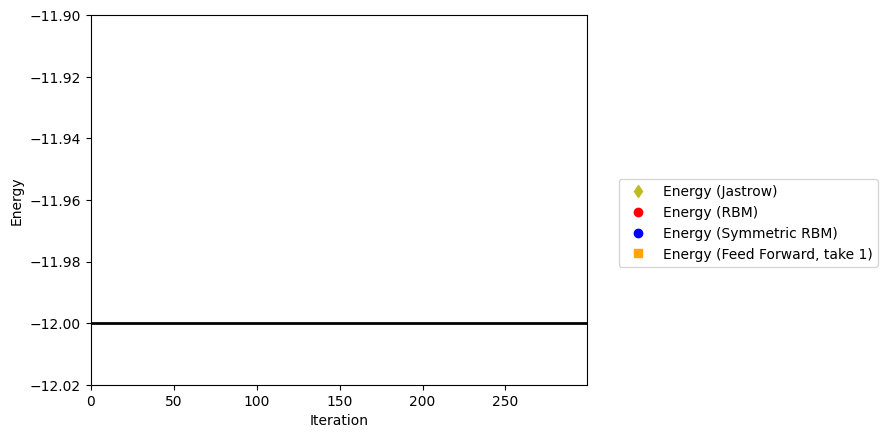

In [22]:
# import the data from log file
data=json.load(open("FF.log"))

# Extract the relevant information
iters_FF = data["Energy"]["iters"]
energy_FF = data["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
ax1.plot(iters_Jastrow, energy_Jastrow, color='C8',linestyle="None", marker='d',label='Energy (Jastrow)')
ax1.plot(iters_RBM, energy_RBM, color='red', marker='o',linestyle="None",label='Energy (RBM)')
ax1.plot(iters_symRBM, energy_symRBM, color='blue',linestyle="None",marker='o',label='Energy (Symmetric RBM)')
ax1.plot(iters_FF, energy_FF, color='orange', marker='s',linestyle="None",label='Energy (Feed Forward, take 1)')
ax1.legend(bbox_to_anchor=(1.05, 0.3))
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_FF[-1],exact_gs_energy-0.02,exact_gs_energy+0.1])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
plt.show()

In [23]:
class Model2(nnx.Module):

    def __init__(self, N: int, *, rngs: nnx.Rngs):
        self.linear1 = nnx.Linear(in_features=N, out_features=2 * N, dtype=jnp.complex128, rngs=rngs)
        self.linear2 = nnx.Linear(in_features=2 * N, out_features=N, dtype=jnp.complex128, rngs=rngs)

    def __call__(self, x: jax.Array):
        x = self.linear1(x)
        x = nk.nn.activation.log_cosh(x)
        x = self.linear2(x)
        x = nk.nn.activation.log_cosh(x)
        return jnp.sum(x, axis=-1)

ffnn2 = Model2(N=hi.size, rngs=nnx.Rngs(1))

# The variational state
vs = nk.vqs.MCState(sa, ffnn, n_samples=1008)

opt = nk.optimizer.Sgd(learning_rate=0.05)

# Stochastic Reconfiguration
sr = nk.optimizer.SR(diag_shift=0.1)

# The ground-state optimization loop
gs = nk.VMC(
    hamiltonian=ha,
    optimizer=op,
    preconditioner=sr,
    variational_state=vs)


start = time.time()
gs.run(out='FF2', n_iter=600)
end = time.time()


print('### Feed Forward (more layers) calculation')
print('Has',vs.n_parameters,'parameters')
print('The Feed Forward (more layers) calculation took',end-start,'seconds')

  0%|                                                                                                         …

### Feed Forward (more layers) calculation
Has 312 parameters
The Feed Forward (more layers) calculation took 30.592809915542603 seconds


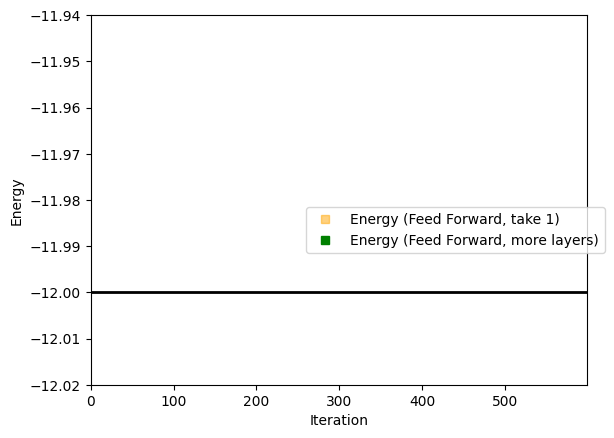

In [24]:
# import the data from log file
data=json.load(open("FF2.log"))

# Extract the relevant information
iters_FF_morelayers = data["Energy"]["iters"]
energy_FF_morelayers = data["Energy"]["Mean"]["real"]

fig, ax1 = plt.subplots()
#ax1.plot(iters_Jastrow, energy_Jastrow, color='C8',linestyle="None", marker='d',label='Energy (Jastrow)')
#ax1.plot(iters_RBM, energy_RBM, color='red', label='Energy (RBM)')
#ax1.plot(iters_symRBM, energy_symRBM, color='blue',linestyle="None",marker='o',label='Energy (Symmetric RBM)')
ax1.plot(iters_FF, energy_FF, color='orange', marker='s',alpha=0.5,linestyle="None",label='Energy (Feed Forward, take 1)')
ax1.plot(iters_FF_morelayers, energy_FF_morelayers, color='green',marker='s',linestyle="None", alpha=1,label='Energy (Feed Forward, more layers)')
ax1.legend(bbox_to_anchor=(1.05, 0.5))
ax1.set_ylabel('Energy')
ax1.set_xlabel('Iteration')
plt.axis([0,iters_RBM[-1],exact_gs_energy-0.02,exact_gs_energy+0.06])
plt.axhline(y=exact_gs_energy, xmin=0,
                xmax=iters_RBM[-1], linewidth=2, color='k', label='Exact')
plt.show()